In [28]:
import keras
import tensorflow
import pandas as pd
import numpy as np

In [29]:
data = pd.read_csv("/content/Churn_Modelling.csv")

In [30]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [31]:
X = data.iloc[:,3:13]
y = data.iloc[:,13]

In [32]:
geography = pd.get_dummies(X["Geography"],drop_first = True)
gender = pd.get_dummies(X["Gender"],drop_first = True)

In [33]:
geography

,Germany,Spain
0,False,False
1,False,True
2,False,False
3,False,False
4,False,True
...,...,...
9995,False,False
9996,False,False
9997,False,False
9998,True,False


In [34]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [35]:
X = pd.concat([X,geography,gender],axis=1)

In [36]:
X = X.drop(columns=["Geography","Gender"],axis=1)

In [37]:
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Germany,Spain,Male
0,619,42,2,0.00,1,1,1,101348.88,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,True,False,True


In [38]:
# Split data in train and test data
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)

In [39]:
# wether we require feature scaling ?? yess but why ?
# because ... if we pass high value inputs then the forwarad propogation computation cost will be high which delays the gradient descenet to converge.

from sklearn.preprocessing import StandardScaler

X_train_scaled = StandardScaler().fit_transform(X_train)
X_test_scaled = StandardScaler().fit_transform(X_test)


In [40]:
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LeakyReLU,ReLU,PReLU,ELU
from keras.layers import Dropout

In [41]:
model = Sequential()

In [42]:
from keras.layers import Input

model.add(Input(shape=(11,)))
model.add(Dense(units=6,kernel_initializer = "he_uniform",activation='relu'))

In [43]:
model.add(Dense(units=10,kernel_initializer = "he_normal",activation='relu'))
model.add(Dense(units=20,kernel_initializer = "he_normal",activation='relu'))
model.add(Dense(units=15,kernel_initializer = "he_normal",activation='relu'))
model.add(Dense(units=1,kernel_initializer = "glorot_uniform",activation='sigmoid'))

In [44]:
model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])

In [45]:
model_history = model.fit(X_train,y_train, validation_split = 0.33, batch_size = 10, epochs = 100)

Epoch 1/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6574 - loss: 225.1535 - val_accuracy: 0.6876 - val_loss: 152.2877
Epoch 2/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6501 - loss: 79.4415 - val_accuracy: 0.7599 - val_loss: 127.6561
Epoch 3/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6589 - loss: 63.4850 - val_accuracy: 0.3328 - val_loss: 66.3208
Epoch 4/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6686 - loss: 58.0082 - val_accuracy: 0.7009 - val_loss: 28.2471
Epoch 5/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6708 - loss: 41.6995 - val_accuracy: 0.7762 - val_loss: 27.6891
Epoch 6/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6901 - loss: 43.3466 - val_accuracy: 0.5222 - val_loss: 17.2682
Epoch 7/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6660 - loss: 47.3920 - val_accuracy: 0.7902 - val_loss: 85.3241
Epoch 8/100
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6830 - loss: 

KeyboardInterrupt: 

In [46]:
print(model_history.history.keys())

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])


In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

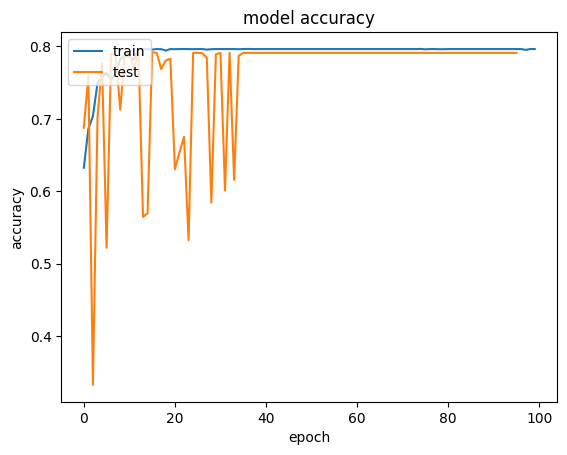

In [47]:
plt.plot(model_history.history['accuracy'])
plt.plot(model.history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [48]:
y_pred = model.predict(X_test) > 0.5

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


In [49]:
y_pred

array([[False],
       [False],
       [False],
       ...,
       [False],
       [False],
       [False]])

In [56]:
from sklearn.metrics import confusion_matrix
accuracy_metric = confusion_matrix(y_test,y_pred)

print(accuracy_metric)

[[1607    0]
 [ 393    0]]


In [59]:
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test,y_pred)
print(score)

0.8035
